Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.620/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
created_new: False
log_path: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.620/kT_0.700/nsteps_1000000/seed_1/randomization_log.hdf5
state_path: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.620/kT_0.700/nsteps_1000000/seed_1/randomization.gsd


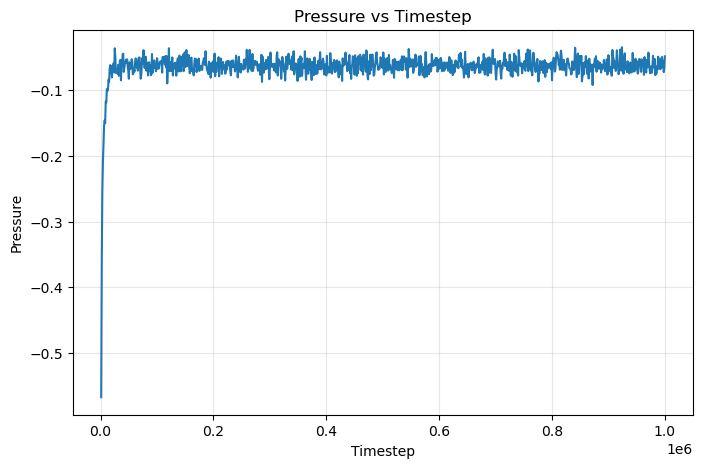

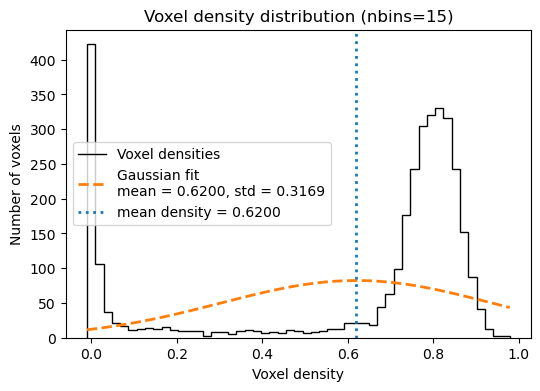

Voxel density summary
nbins:              15
number of voxels:   3375
voxel volume:       51.612899105719464
mean density:       0.6200000494925489
std density:        0.31690064731093187
min density:        0.0
max density:        0.9687500773321076


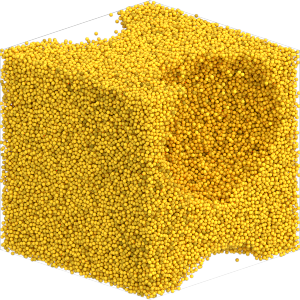

In [14]:
from pathlib import Path
import importlib

from md_Helpers import simulation as sim
from md_Helpers import runs as runs
from md_Helpers import metadata
from md_Helpers import visualization as viz
from md_Helpers import classification

importlib.reload(sim)
importlib.reload(runs)
importlib.reload(metadata)
importlib.reload(viz)
importlib.reload(classification)

# Small test example. Increase n_fcc_cells/nsteps for production.
result = sim.get_or_make_thermalized_state(
    n_fcc_cells=30,
    target_rho=0.620,
    kT=0.700,
    nsteps=1_000_000,
    phase_name="randomization",
    overwrite=False,
    overwrite_lattice=False,
)

log_path = Path(result["paths"]["log_path"])
state_path = Path(result["paths"]["state_path"])

print("created_new:", result["created_new"])
print("log_path:", log_path)
print("state_path:", state_path)

# Plot logs
log = runs.read_hdf5_log(log_path)
viz.plot_log_quantity(log, "pressure")

viz.plot_voxel_histogram(result,nbins=15);
#viz.render(result)